In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from lib.models.regnetv3.modules import XBlockV3, Permute, PositionalEncoding
from lib.models.regnetv3.regnet_encoder import RegNetEncoder
from torch import nn
import torch
from lib.data.dataloading import load_nursing_5_class, load_raw, load_all
from lib.models import RegNetv3
from lib.config import RAW_DIR
from lib.modules import optimization_loop_xonly, optimization_loop_multi_class
from lib.utils import sample_regnet
from tqdm import tqdm
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from lib.models import DAE
import json
import numpy as np
from sklearn.model_selection import train_test_split

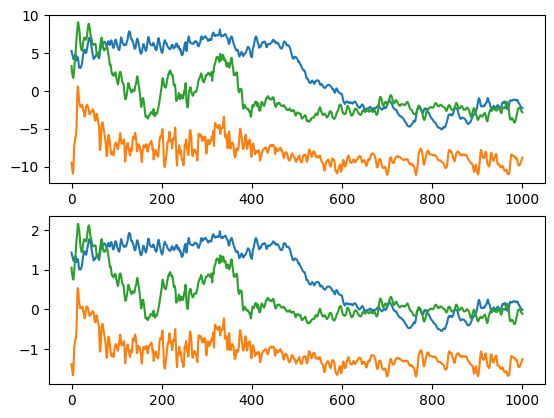

In [10]:
X = next(iter(trainloader))
Xnorm = (X - X.mean(dim=(1,2), keepdim=True)) / (X.std(dim=(1,2), keepdim=True) + 1e-10)
fig, ax = plt.subplots(2)
ax[0].plot(X[0,0])
ax[0].plot(X[0,1])
ax[0].plot(X[0,2])
ax[1].plot(Xnorm[0,0])
ax[1].plot(Xnorm[0,1])
ax[1].plot(Xnorm[0,2])

In [11]:
CONFIG = {
    'WINDOW_SIZE':1001,
    'WINDOW_STRIDE':1001 // 8,
    'NURSING_STRIDE': 1001 // 4,
    'BATCH_SIZE': 512,
    'LEARNING_RATE': 3e-4,
    'CLASS_LR': 3e-4,
    'ENC_LEARNING_RATE': 5e-5,
    'TEST_SIZE': 0.1,
    'NURSING_TEST_SIZE': 0.25,
    'DEVICE': 'cuda:1',
    'MASKPCT': 0.25,
    'PDROPOUT': 0.0
}

# while True:
#     d,w,_ = sample_regnet()
#     CONFIG['DEPTHI'] = d
#     CONFIG['WIDTHI'] = w
#     nparams = sum([p.numel() for p in RegNetDAEv3(CONFIG=CONFIG).parameters()])
#     if nparams > 3_000_000 and nparams < 7_000_000:
#         print(nparams, d, w)
#         break

n=60
nurses = np.random.choice(list(range(11,71)), n, replace=False)
train_nurses, dev_nurses = train_test_split(nurses, test_size=CONFIG['NURSING_TEST_SIZE'])
CONFIG['TRAIN_NURSES'] = train_nurses.tolist()
CONFIG['VALIDATION'] = dev_nurses.tolist()
trainloader, testloader = load_all(
    CONFIG['WINDOW_SIZE'],
    test_size=CONFIG['TEST_SIZE'],
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['WINDOW_STRIDE'],
    nurses_split=(train_nurses, dev_nurses),
)
len(trainloader.dataset), len(testloader.dataset)

model = DAE(CONFIG=CONFIG).to(CONFIG['DEVICE'])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LEARNING_RATE'])
# model.unmask()
outdir = f'dev/10_dae/mask{CONFIG["MASKPCT"]}-64-128-256-512'
# optimization_loop_xonly(
#     model,
#     trainloader,
#     testloader,
#     criterion,
#     optimizer,
#     epochs=1000,
#     patience=20,
#     config=CONFIG,
#     continue_training=False,
#     device=CONFIG['DEVICE'],
#     outdir=outdir,
#     writer=outdir,
#     normalize=True
# )

Using all available sessions
Using Directories: ['2023-11-11_17_50_20.pt', '2023-11-01_15_49_48.pt', '11-10_08_54_24.pt', '10-27_00_21_25.pt', '2023-11-02_13_55_22.pt', '11-08_07_17_47.pt', '11-07_20_24_32.pt', '11-07_17_43_30.pt', '11-01_20_34_28.pt', '11-08_08_27_30.pt', '2023-11-10_13_11_41.pt', '2023-11-01_15_47_52.pt', '11-07_17_29_01.pt', '10-28_13_18_42.pt', '11-07_12_58_43.pt', '11-02_19_28_19.pt', '2023-10-26_15_32_20.pt', '11-07_15_03_24.pt', '11-01_20_54_52.pt', '10-27_09_45_42.pt', '10-27_00_20_15.pt']
Created 660 chunks of length 90000 samples each
Total train length: 6 days, 6:09:00 (54054000 Samples)
Total test length: 16:41:00 (6006000 Samples)


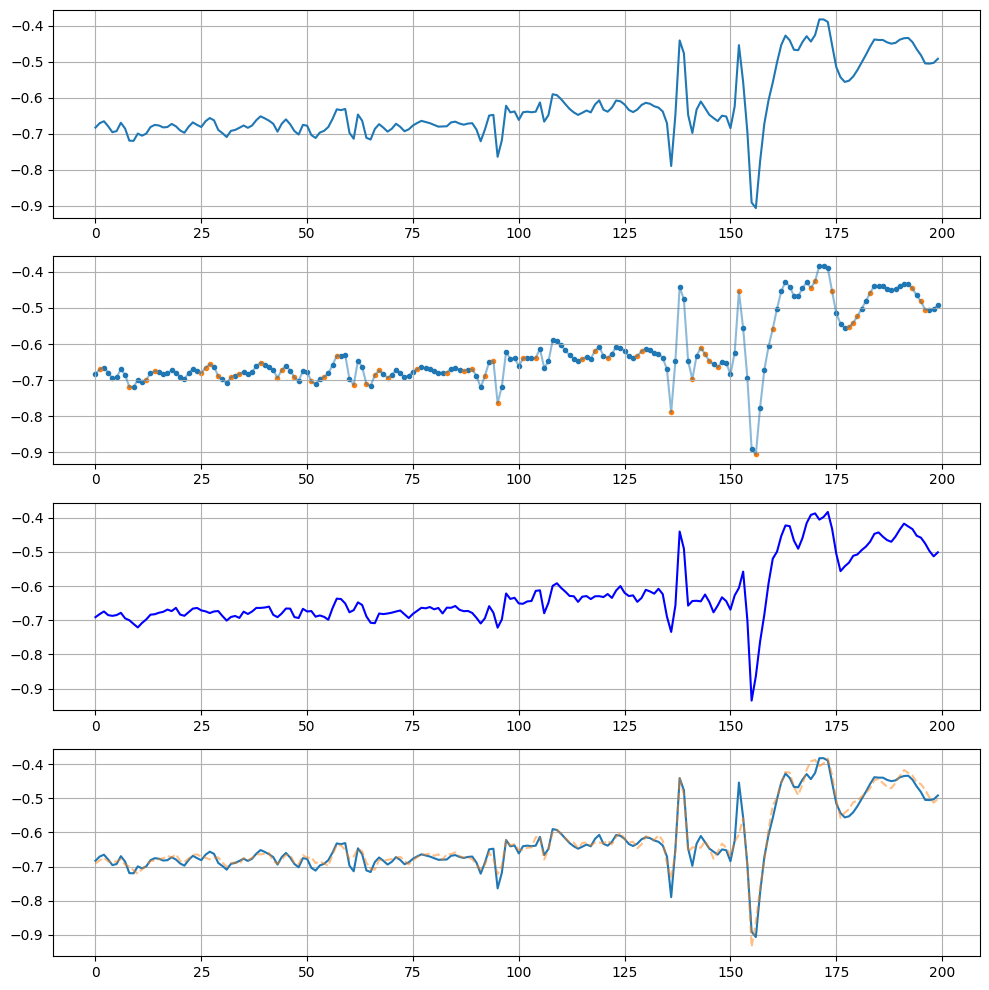

In [12]:
import matplotlib.pyplot as plt
CONFIG = config = json.load(open(f'{outdir}/config.json'))
model = DAE(CONFIG=CONFIG).to(CONFIG['DEVICE'])
model.load_state_dict(torch.load(f'{outdir}/best_model.pt'))
model.unmask()
X = next(iter(testloader))
X = (X - X.mean(dim=(1,2), keepdim=True) ) / (X.std(dim=(1,2), keepdim=True) + 1e-10)
mask = torch.rand(X.shape[0], 1, X.shape[2]) < CONFIG['MASKPCT']
mask = mask.expand(-1, 3, -1)
Xmask = X * ~mask.to(X.device)
x = model(Xmask.to(CONFIG['DEVICE']))
fig, axes = plt.subplots(4, figsize=(10,10))
Xmask = Xmask.detach().cpu().numpy()
l = 200
axes[0].plot(X[0,0,:l].detach().cpu().numpy())
axes[1].plot(X[0,0,:l].detach().cpu().numpy(), alpha=0.5)
axes[1].scatter(torch.arange(l)[Xmask[0,0,:l] != 0], Xmask[0,0,:l][Xmask[0,0,:l] != 0], marker='.')
axes[1].scatter(torch.arange(l)[Xmask[0,0,:l] == 0], X[0,0,:l][Xmask[0,0,:l] == 0], marker='.')
axes[2].plot(x[0,0,:l].detach().cpu().numpy(), color='blue')
axes[3].plot(X[0,0,:l].detach().cpu().numpy())
axes[3].plot(x[0,0,:l].detach().cpu().numpy(), alpha=0.5, linestyle='--')
for ax in axes:
    ax.grid()
plt.tight_layout()

In [14]:
X = next(iter(testloader))
X = (X - X.mean(dim=(1,2), keepdim=True) ) / (X.std(dim=(1,2), keepdim=True) + 1e-10)
logits = model(X.to(CONFIG['DEVICE'])).detach().cpu().numpy()
i = slice(0,10)
df = pd.DataFrame({
    'x': X[i,0].flatten(), 
    'y': X[i,1].flatten(), 
    'z': X[i,2].flatten(), 
    'x_pred': logits[i,0].flatten(), 
    'y_pred': logits[i,1].flatten(), 
    'z_pred': logits[i,2].flatten()
})
fig = px.line(df, x=df.index, y=['x', 'x_pred', 'y', 'y_pred', 'z', 'z_pred'])
fig.show(renderer='browser')

100%|██████████| 20/20 [00:00<00:00, 26.14it/s]


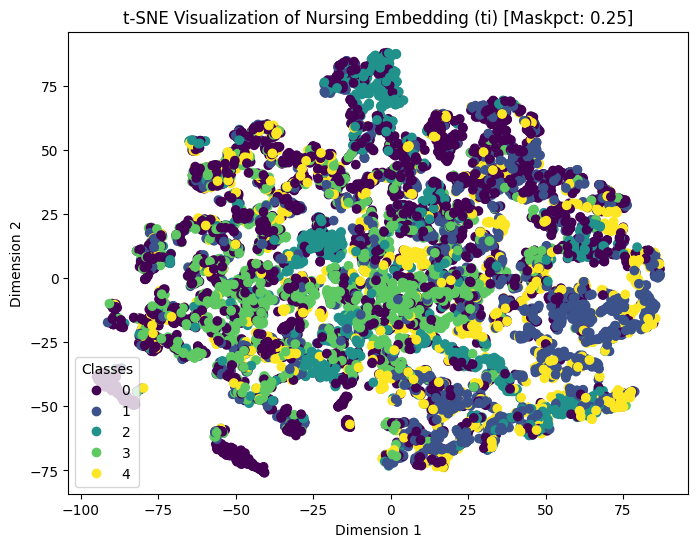

In [15]:
from lib.data.dataloading import load_nursing_5_class

nursing_trainloader, nursing_testloader = load_nursing_5_class(
    range(11,71), 
    CONFIG['WINDOW_SIZE'], 
    test_size=1, 
    batch_size=CONFIG['BATCH_SIZE'],
    stride=CONFIG['WINDOW_SIZE'],
)

embedding = []
Xs = []
ys = []
model.eval()
model.unmask()
for i,(X,y) in enumerate(tqdm(nursing_testloader)):
    with torch.no_grad():
        Xs.append(X)
        ys.append(y)
        X = X.view(-1, 3, CONFIG['WINDOW_SIZE'])
        X = X.to(CONFIG['DEVICE'])
        x = model.e(X)
        embedding.append(x.detach().cpu().mean(dim=2))
    
embedding = torch.cat(embedding, dim=0)
Xs = torch.cat(Xs, dim=0)
ys = torch.cat(ys, dim=0)

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

emb_np = embedding.numpy()

# Applying t-SNE to reduce the dimensions to 2
tsne = TSNE(n_components=2)
data_tsne = tsne.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_tsne[:, 0], data_tsne[:, 1], marker='o', c=ys)#, c=cluster_labels, cmap='viridis')
plt.title(f't-SNE Visualization of Nursing Embedding (ti) [Maskpct: {CONFIG["MASKPCT"]}]')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(*scatter.legend_elements(), loc="lower left", title="Classes")
plt.show()

# 'NONE':0,
# 'Eating':1,
# 'Exercise':2,
# 'Medication':3,
# 'Smoking':4,

# Recurrent

In [ ]:
class RDAE(nn.Module):
    def __init__(
            self, 
            winsize=None, in_channels=3,
            g=1, p_dropout=0, 
            maskpct=0.15, 
            CONFIG=None
        ):
        super().__init__()
        if CONFIG:
            winsize = CONFIG['WINDOW_SIZE']
            maskpct = CONFIG['MASKPCT']

        self.maskpct = maskpct
        self.is_masking = True

        # dont change the name of self.e
        # self.e = RegNetEncoder(winsize, in_channels, stem_out_c, d, w, g, p_dropout)
        w = [64,128,256,512]
        self.e = nn.Sequential(
            nn.Conv1d(in_channels, w[0], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[0],501)),
            nn.Conv1d(w[0], w[1], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[1],251)),
            nn.Conv1d(w[1], w[2], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[2],126)),
            nn.Conv1d(w[2], w[3], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[3],63))
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(w[3], w[2], kernel_size=3, stride=2, padding=1),
            nn.Upsample(size=126),
            nn.ReLU(),
            nn.LayerNorm((w[2],126)),
            nn.ConvTranspose1d(w[2], w[1], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[1],251)),
            nn.ConvTranspose1d(w[1], w[0], kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.LayerNorm((w[0],501)),
            nn.ConvTranspose1d(w[0], in_channels, kernel_size=3, stride=2, padding=1),
        )
    def forward(self, x, mask=True):
        x = (x - x.mean(dim=(1,2), keepdim=True)) / (x.std(dim=(1,2), keepdim=True) + 1e-10)
        if self.is_masking:
            mask = torch.rand(x.shape[0], 1, x.shape[2]) < self.maskpct
            mask = mask.expand(-1, 3, -1)
            x = x * ~mask.to(x.device)
        x = self.e(x)
        x = self.decoder(x)
        return x

    def mask(self):
        self.is_masking = True
    def unmask(self):
        self.is_masking = False